Assumptions used for the occupancy anchor:
- Room: `50 x 30 x 15 ft`
- Outdoor CO2: `420 ppm`
- Baseline ACH fallback: `4`
- Airflow proxy: `Discharge Air Flow` from the FPB export, converted to ACH
- CO2 generation per person: `0.018 m^3/h/person`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
ROOT = Path.cwd()
ROOM_VOLUME_FT3 = 50 * 30 * 15
ROOM_VOLUME_M3 = ROOM_VOLUME_FT3 * 0.0283168
BASELINE_ACH = 4.0


def load_point_history(path: Path, rename_map: dict[str, str]) -> pd.DataFrame:
    raw = pd.read_csv(path)
    raw['time'] = pd.to_datetime(raw['dateTimeUtc'], errors='coerce')
    raw['value'] = pd.to_numeric(raw['value'], errors='coerce')

    wide = (
        raw.loc[raw['pointDisplayName'].isin(rename_map), ['time', 'pointDisplayName', 'value']]
        .dropna(subset=['time'])
        .pivot_table(index='time', columns='pointDisplayName', values='value', aggfunc='mean')
        .sort_index()
        .rename(columns=rename_map)
        .resample('5min')
        .mean()
    )

    wide.columns.name = None
    return wide


iaq = load_point_history(
    ROOT / 'data' / '354_IAQ_30day(03-28-2026).csv',
    {
        'CO2': 'co2_iaq',
        'VOC': 'voc',
        'Zone Air Humid': 'humidity_iaq',
        'Zone Temp': 'temp_iaq',
    },
)

fpb = load_point_history(
    ROOT / 'data' / '354_FPB_30day(03-28-2026).csv',
    {
        'Zone CO2': 'co2_fpb',
        'Zone Air Humid': 'humidity_fpb',
        'Zone Temp': 'temp_fpb',
        'Discharge Air Flow': 'airflow_cfm',
    },
)

merged = iaq.join(fpb, how='outer')
merged['co2'] = merged[['co2_iaq', 'co2_fpb']].mean(axis=1)
merged['humidity'] = merged[['humidity_iaq', 'humidity_fpb']].mean(axis=1)
merged['temperature'] = merged[['temp_iaq', 'temp_fpb']].mean(axis=1)
merged['airflow_ach'] = merged['airflow_cfm'] * 60 / ROOM_VOLUME_FT3

merged = merged[['voc', 'co2', 'humidity', 'temperature', 'airflow_cfm', 'airflow_ach']].copy()
merged.head()

,voc,co2,humidity,temperature,airflow_cfm,airflow_ach
time,,,,,,
2026-02-27 06:00:00,75.200000,439.666667,42.099998,69.764000,1101.133154,2.936355
2026-02-27 06:05:00,75.833333,438.333333,NaN,NaN,1099.971476,2.933257
2026-02-27 06:10:00,74.750000,436.300000,NaN,NaN,1105.634473,2.948359
2026-02-27 06:15:00,71.666667,435.333333,43.350000,70.106001,1100.777435,2.935406
2026-02-27 06:20:00,73.000000,435.400000,NaN,NaN,1105.474426,2.947932


In [2]:
# Occupancy estimate using CO2 plus airflow-aware ventilation proxy

def minmax_robust(series: pd.Series, q_low: float = 0.05, q_high: float = 0.95) -> pd.Series:
    x = series.copy()
    lo = x.quantile(q_low)
    hi = x.quantile(q_high)
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        return pd.Series(0.0, index=x.index)
    y = (x - lo) / (hi - lo)
    return y.clip(0, 1)


C_OUT = 420.0
G_PERSON = 0.018

# Use measured discharge airflow when available; otherwise fall back to the baseline ACH.
merged['ach_effective'] = merged['airflow_ach'].fillna(BASELINE_ACH)
q_m3_h = merged['ach_effective'] * ROOM_VOLUME_M3
co2_delta = (merged['co2'] - C_OUT).clip(lower=0)
merged['people_co2_anchor'] = q_m3_h * (co2_delta * 1e-6) / G_PERSON

# Multi-feature occupancy index from CO2/VOC/Humidity/Temp.
# Airflow is already used above in the CO2 anchor, so it is not weighted again here.
co2_n = minmax_robust(merged['co2'])
voc_n = minmax_robust(merged['voc'])
hum_n = minmax_robust(merged['humidity'])
temp_n = minmax_robust(merged['temperature'])

feature_index = (
    0.45 * co2_n.fillna(0) +
    0.30 * voc_n.fillna(0) +
    0.15 * hum_n.fillna(0) +
    0.10 * temp_n.fillna(0)
)

anchor_p95 = merged['people_co2_anchor'].quantile(0.95)
merged['people_feature_scaled'] = feature_index * anchor_p95
merged['people_estimated'] = (
    0.70 * merged['people_co2_anchor'].fillna(0) +
    0.30 * merged['people_feature_scaled'].fillna(0)
).rolling(3, min_periods=1).mean()

merged[['people_co2_anchor', 'people_feature_scaled', 'people_estimated', 'ach_effective']].describe().round(2)

,people_co2_anchor,people_feature_scaled,people_estimated,ach_effective
count,8525.00,8618.00,8618.00,8618.00
mean,4.17,4.43,4.22,3.29
std,7.61,4.39,6.40,0.80
min,0.00,0.00,0.00,2.33
25%,0.00,0.88,0.40,2.94
50%,0.82,3.16,1.56,2.96
75%,4.52,6.29,4.91,3.02
max,70.64,19.07,46.00,6.10


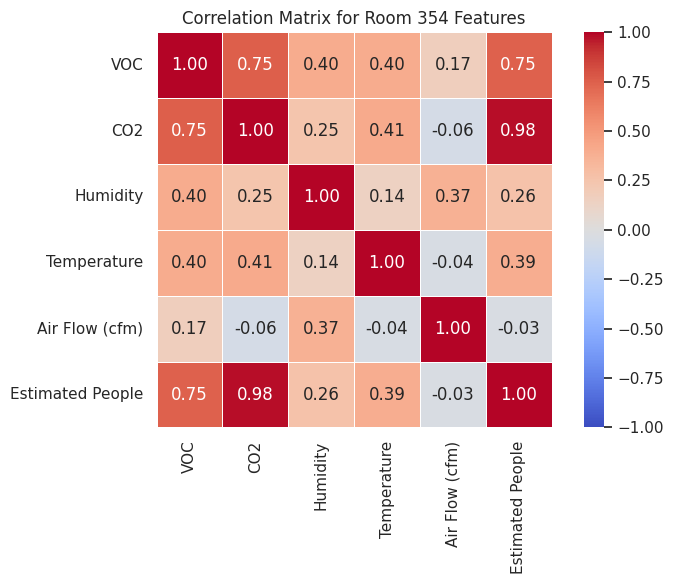

,VOC,CO2,Humidity,Temperature,Air Flow (cfm),Estimated People
VOC,1.000,0.751,0.402,0.401,0.172,0.748
CO2,0.751,1.000,0.246,0.414,-0.064,0.978
Humidity,0.402,0.246,1.000,0.143,0.371,0.265
Temperature,0.401,0.414,0.143,1.000,-0.042,0.392
Air Flow (cfm),0.172,-0.064,0.371,-0.042,1.000,-0.031
Estimated People,0.748,0.978,0.265,0.392,-0.031,1.000


In [3]:
# Correlation matrix for the merged room-level features
corr_df = merged[
    ['voc', 'co2', 'humidity', 'temperature', 'airflow_cfm', 'people_estimated']
].rename(columns={
    'voc': 'VOC',
    'co2': 'CO2',
    'humidity': 'Humidity',
    'temperature': 'Temperature',
    'airflow_cfm': 'Air Flow (cfm)',
    'people_estimated': 'Estimated People',
})

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Matrix for Room 354 Features')
plt.tight_layout()
plt.show()

corr_matrix.round(3)

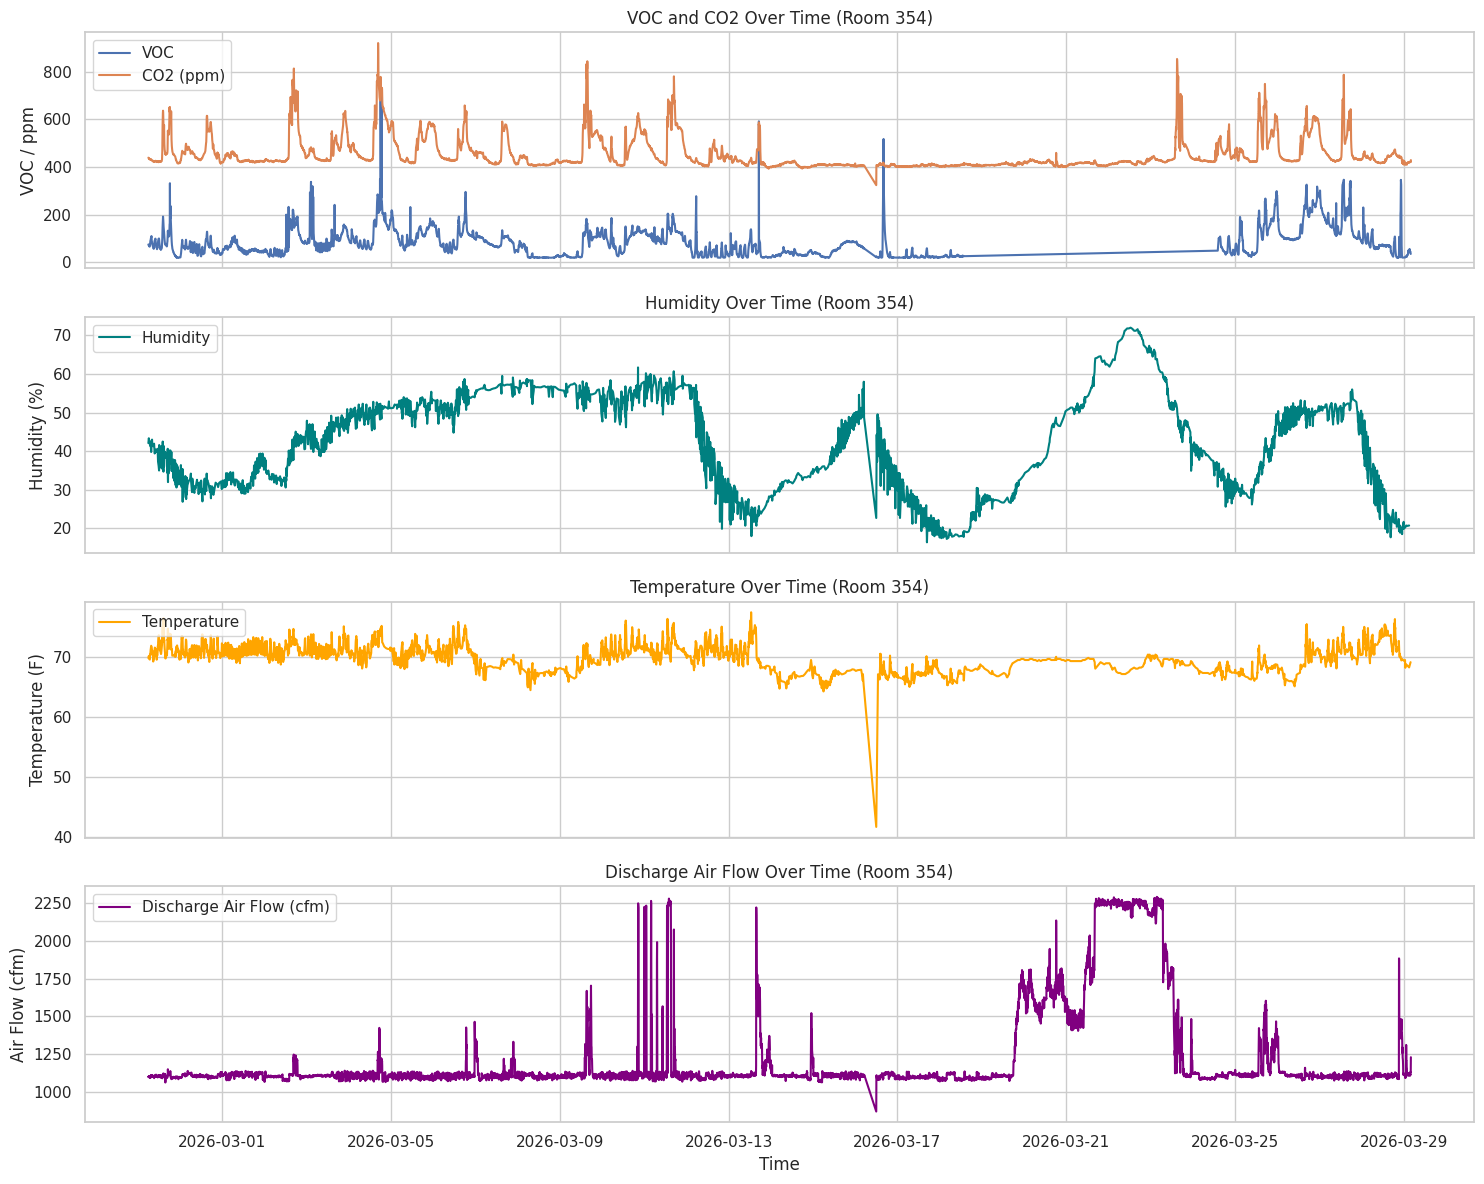

In [4]:
# 4-panel feature comparison
plot_df = merged.copy().reset_index().rename(columns={'index': 'time'})

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# 1) VOC + CO2
sns.lineplot(data=plot_df, x='time', y='voc', ax=axes[0], label='VOC')
sns.lineplot(data=plot_df, x='time', y='co2', ax=axes[0], label='CO2 (ppm)')
axes[0].set_title('VOC and CO2 Over Time (Room 354)')
axes[0].set_ylabel('VOC / ppm')
axes[0].legend(loc='upper left')

# 2) Humidity
sns.lineplot(data=plot_df, x='time', y='humidity', ax=axes[1], color='teal', label='Humidity')
axes[1].set_title('Humidity Over Time (Room 354)')
axes[1].set_ylabel('Humidity (%)')
axes[1].legend(loc='upper left')

# 3) Temperature
sns.lineplot(data=plot_df, x='time', y='temperature', ax=axes[2], color='orange', label='Temperature')
axes[2].set_title('Temperature Over Time (Room 354)')
axes[2].set_ylabel('Temperature (F)')
axes[2].legend(loc='upper left')

# 4) Airflow / ACH proxy
sns.lineplot(data=plot_df, x='time', y='airflow_cfm', ax=axes[3], color='purple', label='Discharge Air Flow (cfm)')
axes[3].set_title('Discharge Air Flow Over Time (Room 354)')
axes[3].set_ylabel('Air Flow (cfm)')
axes[3].legend(loc='upper left')

axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()

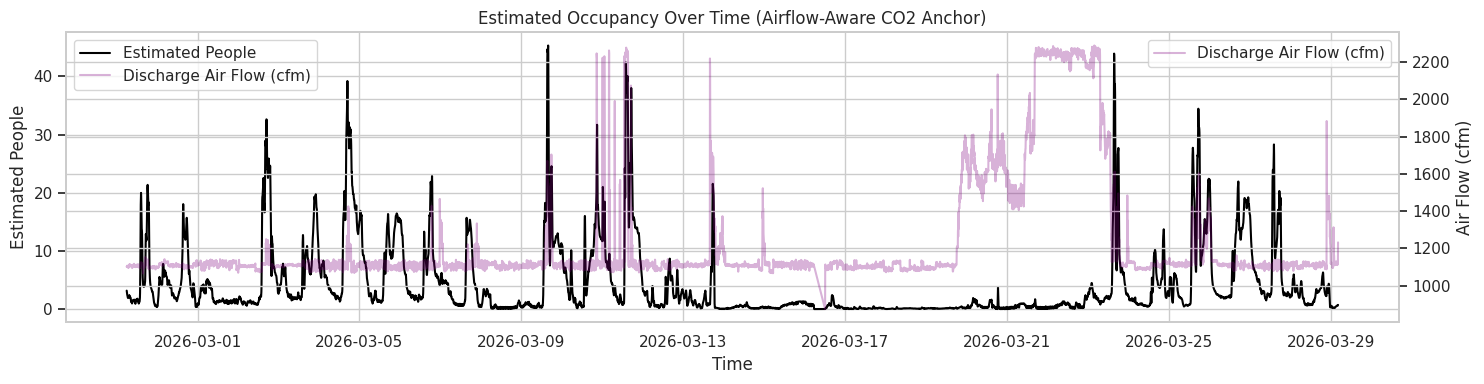

In [5]:
# Estimated occupancy over time
plot_df = merged.copy()
occ_smooth = plot_df['people_estimated'].rolling(3, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(15, 4))
sns.lineplot(x=plot_df.index, y=occ_smooth, ax=ax1, color='black', label='Estimated People')
ax1.set_title('Estimated Occupancy Over Time (Airflow-Aware CO2 Anchor)')
ax1.set_ylabel('Estimated People')
ax1.set_xlabel('Time')

ax2 = ax1.twinx()
sns.lineplot(x=plot_df.index, y=plot_df['airflow_cfm'], ax=ax2, color='purple', alpha=0.3, label='Discharge Air Flow (cfm)')
ax2.set_ylabel('Air Flow (cfm)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
# Optional quick summary
s = merged['people_estimated'].dropna()
air = merged['airflow_cfm'].dropna()
ach = merged['ach_effective'].dropna()

print(f'Mean estimate: {s.mean():.1f} people')
print(f'P90 estimate: {s.quantile(0.90):.1f}')
print(f'P95 estimate: {s.quantile(0.95):.1f}')
print(f'P99 estimate: {s.quantile(0.99):.1f}')
print(f'Max estimate: {s.max():.1f}')
print(f'Airflow coverage: {merged["airflow_cfm"].notna().mean():.1%}')
print(f'Median discharge airflow: {air.median():.0f} cfm')
print(f'Median effective ACH: {ach.median():.2f}')

Mean estimate: 4.2 people
P90 estimate: 13.4
P95 estimate: 17.9
P99 estimate: 29.8
Max estimate: 46.0
Airflow coverage: 98.0%
Median discharge airflow: 1111 cfm
Median effective ACH: 2.96
